In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# external imports
from pathlib import Path
import os
from dotenv import load_dotenv
from torch_geometric.data import Batch
import torch
import random

In [3]:
# internal imports
from primaite.network.generator import NetworkGenerator
from primaite.agents.aegis.modules.openai import OpenAIClient


2024-09-10 10:33:10.362018: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-10 10:33:10.393894: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-10 10:33:10.964058: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/sam/projects/PrimAITE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sam/projects/PrimAITE/.venv/lib/python3.10/site-packages/pydantic/_internal/_fields.py:161: UserWarning: Field "model_id" has conflict with protected name

In [4]:
# constants
NUMBER_OF_NODES = (10, 20)
RANDOM_SEED = 165116
TRAINING_CONFIG_PATH = Path("../agents") / "training_configs" / "do_nothing.yaml"
SERVICE_NAMES = ["HTTP", "SSH", "FTP"]
PORTS_LIST = ["80", "22", "21"]
DATASET_SAVE_PATH = Path("../data") / "generated_data" / "data.pt"
DATASET_SIZE = 3

In [5]:
load_dotenv() 
open_ai_key = os.getenv('OPEN_AI_KEY')

openai = OpenAIClient(api_key=open_ai_key)

2024-09-10 10:33:15,448: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-10 10:33:15,478: Environment configuration loaded
2024-09-10 10:33:15,582: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7f237cc49270> observation component
2024-09-10 10:33:15,584: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-10 10:33:15,585: The output directory for this session is: /home/sam/primaite/2.0.1/sessions/2024-09-10/2024-09-10_10-33-15


{'end_step': 121, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '0', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'ON', 'start_step': 117, 'state': 'ON', 'targetNodeId': '4', 'type': 'OPERATING'}
{'end_step': 78, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '3', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'BOOTING', 'start_step': 60, 'state': 'BOOTING', 'targetNodeId': '4', 'type': 'OPERATING'}
{'end_step': 105, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '6', 'protocol': 'SSH', 'sourceNodeId': '5', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'OVERWHELMED', 'start_step': 48, 'state': 'OVERWHELMED', 'targetNodeId': '6', 'type': 'OS'}
{'end_step': 108, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '7', 'protocol': 'FTP', 'sourceNodeId': '0', 'sourceNodeService': 'FTP', 'sourceNodeServiceState': 'NONE', 

2024-09-10 10:33:17,523: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-10 10:33:17,553: Environment configuration loaded
2024-09-10 10:33:17,644: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7f237c891ea0> observation component
2024-09-10 10:33:17,646: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-10 10:33:17,647: The output directory for this session is: /home/sam/primaite/2.0.1/sessions/2024-09-10/2024-09-10_10-33-17


{'end_step': 121, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '0', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'ON', 'start_step': 117, 'state': 'ON', 'targetNodeId': '4', 'type': 'OPERATING'}
{'end_step': 78, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '3', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'BOOTING', 'start_step': 60, 'state': 'BOOTING', 'targetNodeId': '4', 'type': 'OPERATING'}
{'end_step': 105, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '6', 'protocol': 'SSH', 'sourceNodeId': '5', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'OVERWHELMED', 'start_step': 48, 'state': 'OVERWHELMED', 'targetNodeId': '6', 'type': 'OS'}
{'end_step': 108, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '7', 'protocol': 'FTP', 'sourceNodeId': '0', 'sourceNodeService': 'FTP', 'sourceNodeServiceState': 'NONE', 

2024-09-10 10:33:17,777: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-10 10:33:17,806: Environment configuration loaded
2024-09-10 10:33:17,942: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7f237c763280> observation component
2024-09-10 10:33:17,945: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-10 10:33:17,945: The output directory for this session is: /home/sam/primaite/2.0.1/sessions/2024-09-10/2024-09-10_10-33-17


...

2024-09-10 10:33:20,775: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7f237c760eb0> observation component
2024-09-10 10:33:20,778: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-10 10:33:20,779: The output directory for this session is: /home/sam/primaite/2.0.1/sessions/2024-09-10/2024-09-10_10-33-20
2024-09-10 10:33:22,945: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-10 10:33:22,979: Environment configuration loaded
2024-09-10 10:33:23,072: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7f237c987940> observation component
2024-09-10 10:33:23,074: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-10 10:33:23,075: The output directory for this session is: /home/sam/primaite/2.0.1/sessions/2024-09-10/2024-09-10_10-33-22


{'end_step': 128, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'HTTP', 'sourceNodeId': '1', 'sourceNodeService': 'HTTP', 'sourceNodeServiceState': 'COMPROMISED', 'start_step': 123, 'state': 'COMPROMISED', 'targetNodeId': '4', 'type': 'SERVICE'}
{'end_step': 120, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '3', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'BOOTING', 'start_step': 112, 'state': 'BOOTING', 'targetNodeId': '4', 'type': 'OPERATING'}
{'end_step': 113, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '16', 'protocol': 'SSH', 'sourceNodeId': '7', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'COMPROMISED', 'start_step': 107, 'state': 'COMPROMISED', 'targetNodeId': '16', 'type': 'SERVICE'}
{'end_step': 96, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '5', 'protocol': 'FTP', 'sourceNodeId': '1', 'sourceNodeService': 'FTP', 'source

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

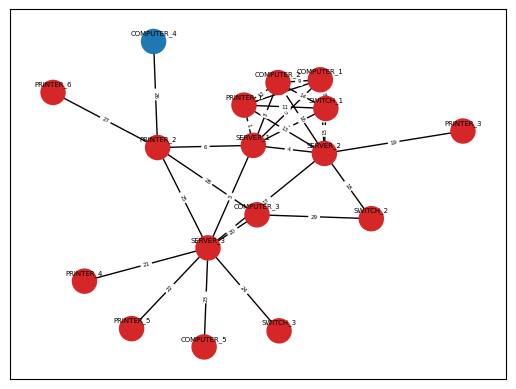

In [6]:
outputs = []
for i in range(DATASET_SIZE):
    laydown_save_path = Path("../data") / "notebook_generated" / "laydowns" / f"{i}.yaml"

    generator = NetworkGenerator(graph_size=random.randint(NUMBER_OF_NODES[0], NUMBER_OF_NODES[1]), training_config_path=TRAINING_CONFIG_PATH, random_seed=1729, services=SERVICE_NAMES, ports=PORTS_LIST, pretrained_llm=openai)

    output = generator.run_end_to_end(laydown_save_path=laydown_save_path)
    outputs.append(output)

    print(f"\nPROGRESS -------> {i + 1} of {DATASET_SIZE} datasets generated\n")

In [7]:
print(generator.network_description)


Nodes:
[
  {
    "Name":"SERVER_1",
    "Type":"SERVER"
  },
  {
    "Name":"COMPUTER_1",
    "Type":"COMPUTER"
  },
  {
    "Name":"PRINTER_1",
    "Type":"PRINTER"
  },
  {
    "Name":"SWITCH_1",
    "Type":"SWITCH"
  },
  {
    "Name":"COMPUTER_2",
    "Type":"COMPUTER"
  },
  {
    "Name":"SERVER_2",
    "Type":"SERVER"
  },
  {
    "Name":"SERVER_3",
    "Type":"SERVER"
  },
  {
    "Name":"PRINTER_2",
    "Type":"PRINTER"
  },
  {
    "Name":"COMPUTER_3",
    "Type":"COMPUTER"
  },
  {
    "Name":"SWITCH_2",
    "Type":"SWITCH"
  },
  {
    "Name":"PRINTER_3",
    "Type":"PRINTER"
  },
  {
    "Name":"COMPUTER_4",
    "Type":"COMPUTER"
  },
  {
    "Name":"PRINTER_4",
    "Type":"PRINTER"
  },
  {
    "Name":"PRINTER_5",
    "Type":"PRINTER"
  },
  {
    "Name":"COMPUTER_5",
    "Type":"COMPUTER"
  },
  {
    "Name":"SWITCH_3",
    "Type":"SWITCH"
  },
  {
    "Name":"PRINTER_6",
    "Type":"PRINTER"
  }
]

Links:
[
  {
    "Name":"0",
    "Source Node":"SERVER_1",
    "Destinat

In [8]:
outputs[0]

Data(edge_index=[2, 52], id=[52], num_nodes=15, x=[15, 6], reasoning='Considering the network configuration and the potential vulnerability of nodes, the node PRINTER_1 is most vulnerable and requires immediate action to prevent further attack.', chosen_node='PRINTER_1', node_property='HARDWARE', property_action='TURN_OFF', service_name='NONE', laydown_filename='0.yaml')

In [9]:
generator.nodes_dict

{'0': SERVER_1,
 '1': COMPUTER_1,
 '2': PRINTER_1,
 '3': SWITCH_1,
 '4': COMPUTER_2,
 '5': SERVER_2,
 '6': SERVER_3,
 '7': PRINTER_2,
 '8': COMPUTER_3,
 '9': SWITCH_2,
 '10': PRINTER_3,
 '11': COMPUTER_4,
 '12': PRINTER_4,
 '13': PRINTER_5,
 '14': COMPUTER_5,
 '15': SWITCH_3,
 '16': PRINTER_6}

In [10]:
# batch = Batch.from_data_list(outputs)
# torch.save(batch, DATASET_SAVE_PATH)